In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.tsa.api as tsa
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

# READING THE TIME SERIES DATA AND PERFORMING EDA ON IT

In [7]:
df = pd.read_csv("gemini-code-1780370065631.csv")
df

,Week of the month,Day of the week,Non-urgent order,Urgent order,Order type A,Order type B,Order type C,Fiscal sector orders,Orders from the traffic controller sector,Banking orders (1),Banking orders (2),Banking orders (3),Target (Total orders)
0,1,4,316.307,223.270,61.543,175.586,302.448,0.000,65556,44914,188411,14793,539.577
1,1,5,128.633,96.042,38.058,56.037,130.580,0.000,40419,21399,89461,7679,224.675
2,1,6,43.651,84.375,21.826,25.125,82.461,1.386,11992,3452,21305,14947,129.412
3,2,2,171.297,127.667,41.542,113.294,162.284,18.156,49971,33703,69054,18423,317.120
4,2,3,90.532,113.526,37.679,56.618,116.220,6.459,48534,19646,16411,20257,210.517
5,2,4,110.925,96.360,30.792,50.704,125.868,79.000,52042,8773,47522,24966,207.364
6,2,5,144.124,118.919,43.304,66.371,153.368,0.000,46573,33597,48269,20973,263.043
7,2,6,119.379,113.870,38.584,85.961,124.413,15.709,35033,26278,56665,18502,248.958
8,3,2,218.856,124.381,33.973,148.274,162.044,1.054,66612,19461,103376,10458,344.291
9,3,3,146.518,101.045,36.399,43.306,168.723,865.000,58224,7742,82395,11948,248.428


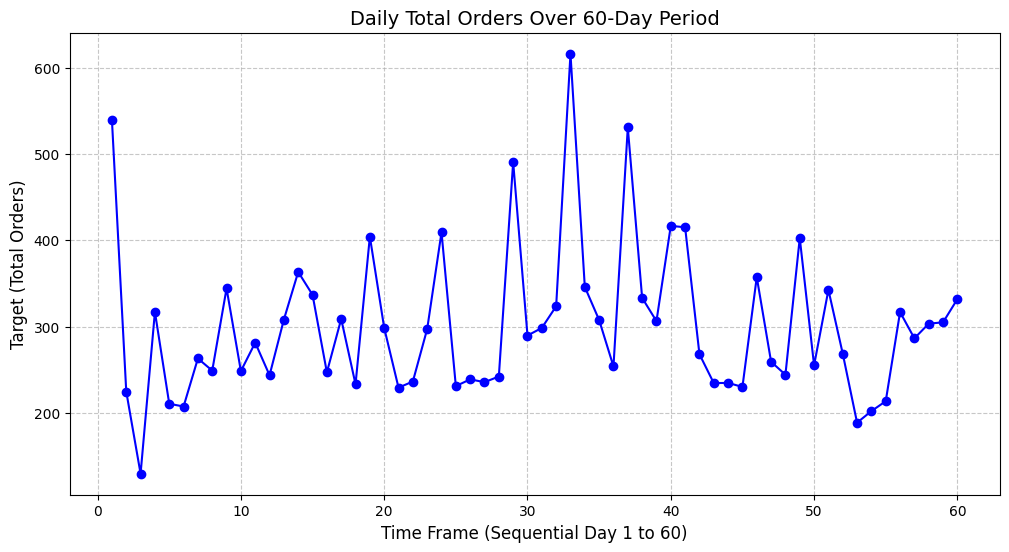

In [8]:
df['Day Sequence'] = df.index + 1

# Plotting the Time Series
plt.figure(figsize=(12, 6))
plt.plot(df['Day Sequence'], df['Target (Total orders)'], marker='o', linestyle='-', color='b')

# Formatting the plot
plt.title('Daily Total Orders Over 60-Day Period', fontsize=14)
plt.xlabel('Time Frame (Sequential Day 1 to 60)', fontsize=12)
plt.ylabel('Target (Total Orders)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('brazilian_data_distribution.png')

## PERFORMING STATIONARITY TEST ON THE DATA

In [9]:
target = df['Target (Total orders)']
result = adfuller(target)
print(f'ADF Statistic: {result[0]: 0.4f}')
for key,value in result[4].items():
    print(f'\t{key}: {value:.4f}')

ADF Statistic: -7.4949
	1%: -3.5464
	5%: -2.9119
	10%: -2.5937


###### This data is stationary an its statistical properties are invariant with respect to time.
###### But inorder to make it stationary we have 2 methods
###### 1. Differencing
###### 2. Logarithmic Transformation
###### 3. Box-Cox Transform

## PERFORMING AUTOCORRELATION AND PARTIAL AUTOCORRELATION(RAW DATA, LOG TRANSFORMED DATA

######No correlation is shown as every  correlation is
###### statistically insignificant

Plots saved to autocorrelation_plots.png


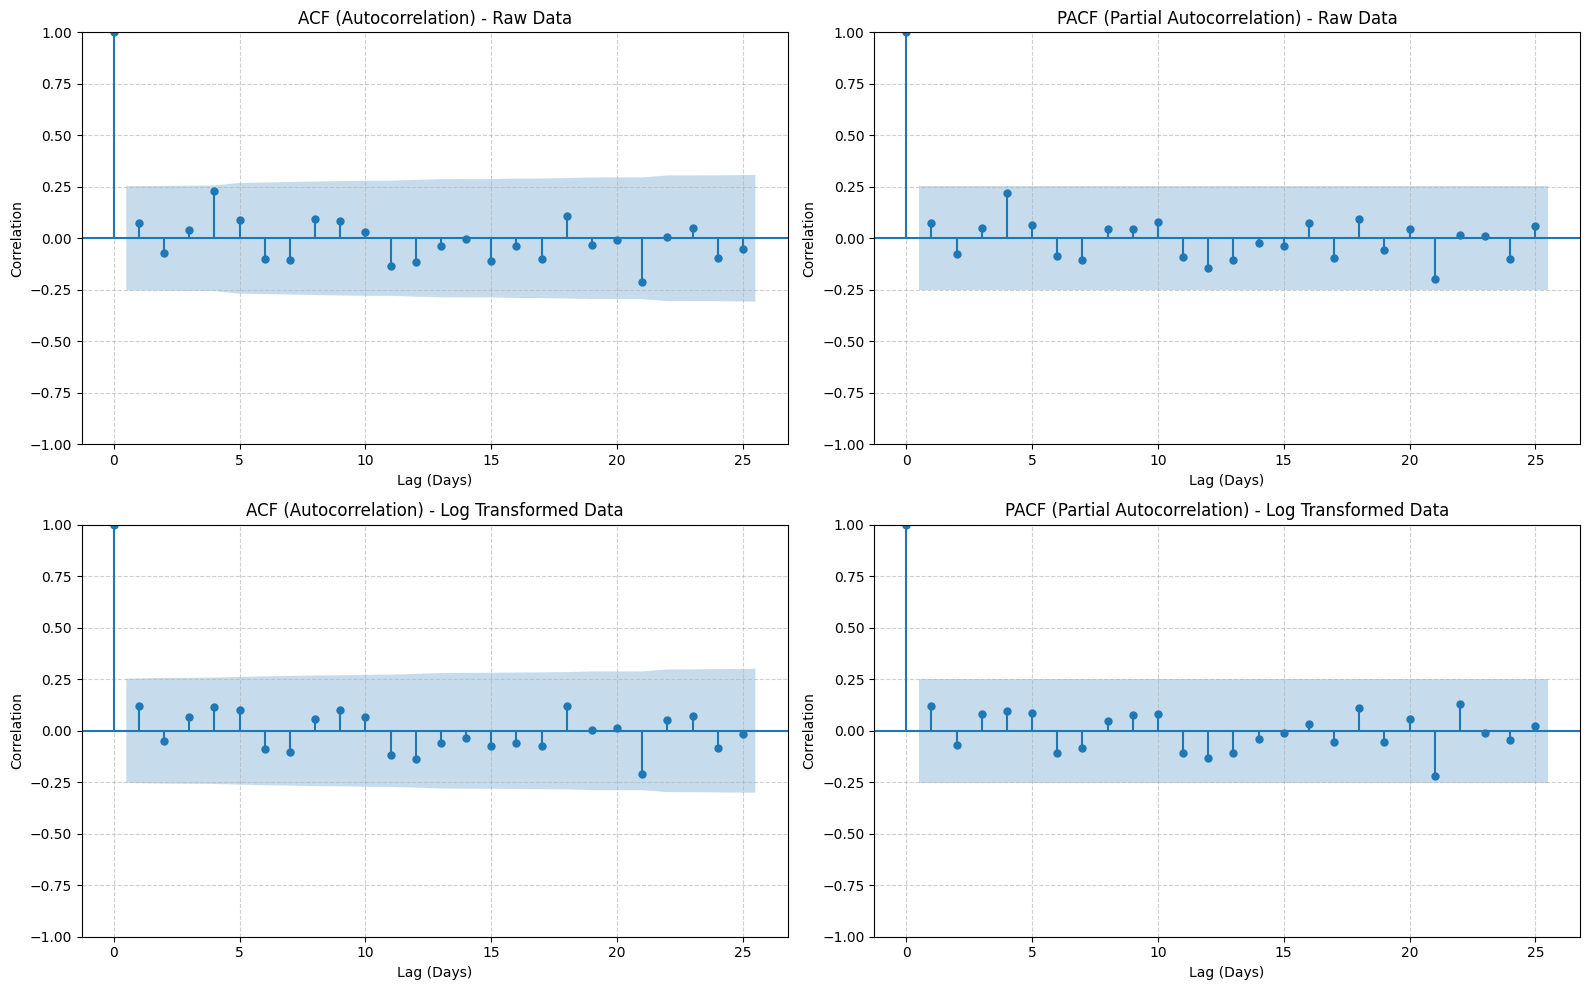

In [10]:
# Create the plots
log_target = np.log(target)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Raw Data Autocorrelation
plot_acf(target, lags=25, ax=axes[0, 0], title='ACF (Autocorrelation) - Raw Data')
plot_pacf(target, lags=25, ax=axes[0, 1], title='PACF (Partial Autocorrelation) - Raw Data')

# Log-Transformed Data Autocorrelation
plot_acf(log_target, lags=25, ax=axes[1, 0], title='ACF (Autocorrelation) - Log Transformed Data')
plot_pacf(log_target, lags=25, ax=axes[1, 1], title='PACF (Partial Autocorrelation) - Log Transformed Data')

# Formatting
for ax in axes.flat:
    ax.set_xlabel('Lag (Days)')
    ax.set_ylabel('Correlation')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('autocorrelation_plots.png')
print("Plots saved to autocorrelation_plots.png")


## Implementing a Simple ARIMA Model

Given the lack of significant autocorrelation in the data, a simple ARIMA model (especially with low orders for p and q) might not yield strong predictive power. However, we'll demonstrate its implementation.

*   **ARIMA(p, d, q) orders:**
    *   `p`: Order of the Autoregressive (AR) part (number of past observations to use).
    *   `d`: Order of differencing (number of times the raw observations are differenced to make the series stationary). Since our data is already stationary, `d=0`.
    *   `q`: Order of the Moving Average (MA) part (number of past forecast errors to use).

In [11]:
# For demonstration, let's try a simple ARIMA(1,0,1) model.
# Given the ACF/PACF plots, a (0,0,0) might be more appropriate if there's truly no correlation.
# However, (1,0,1) is a common starting point for simple models.

# Instantiate the ARIMA model
# d=0 because the ADF test indicated the series is already stationary.
# p and q are chosen to be 1 as a basic starting point, but could be 0 if no correlation is desired.
model = tsa.ARIMA(target, order=(1, 0, 1))

# Fit the model
results = model.fit()

# Display the model summary
print(results.summary())

                                 SARIMAX Results                                 
Dep. Variable:     Target (Total orders)   No. Observations:                   60
Model:                    ARIMA(1, 0, 1)   Log Likelihood                -354.075
Date:                   Sat, 06 Jun 2026   AIC                            716.150
Time:                           04:32:27   BIC                            724.528
Sample:                                0   HQIC                           719.427
                                    - 60                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        301.2369     17.534     17.180      0.000     266.871     335.603
ar.L1         -0.2589      1.442     -0.180      0.857      -3.085       2.567
ma.L1          0.3581      1

The summary provides details about the model, including coefficients, standard errors, p-values, and information criteria. Notice the p-values for the AR and MA coefficients. If they are high (e.g., > 0.05), it suggests that these terms are not statistically significant, reinforcing the idea that these components might not be crucial for this particular series.

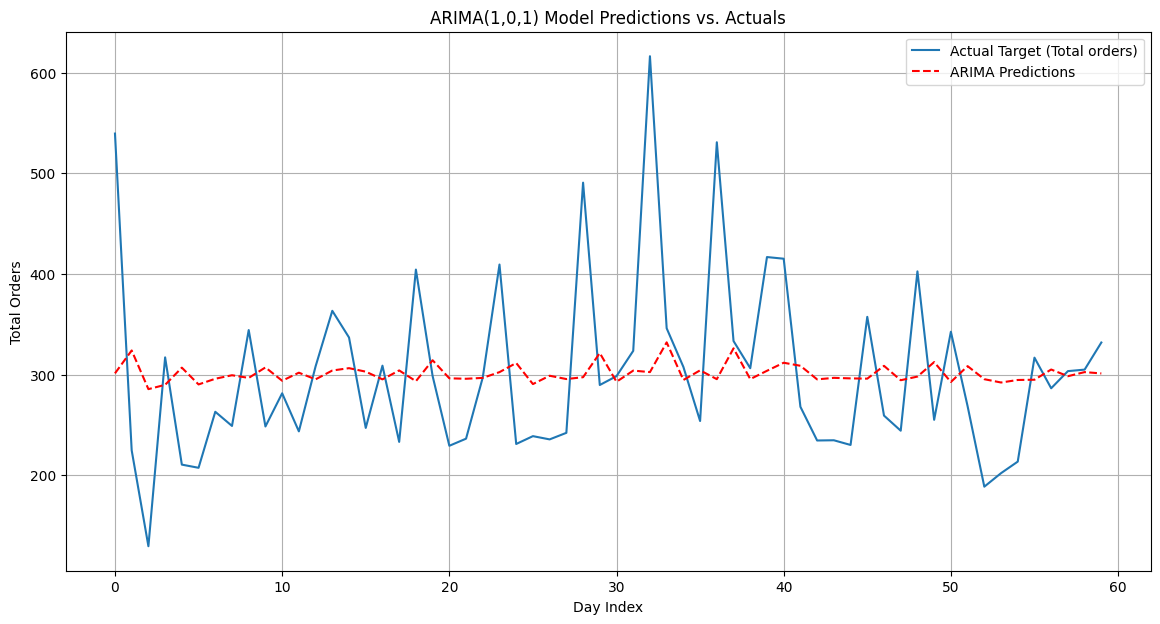

Root Mean Squared Error (RMSE): 88.49


In [12]:
# Make predictions (in-sample for demonstration)
# Let's predict over the entire period the model was trained on
predictions = results.predict(start=0, end=len(target) - 1, typ='levels')

# Plot the original series and the predictions
plt.figure(figsize=(14, 7))
plt.plot(target.index, target, label='Actual Target (Total orders)')
plt.plot(predictions.index, predictions, color='red', linestyle='--', label='ARIMA Predictions')
plt.title('ARIMA(1,0,1) Model Predictions vs. Actuals')
plt.xlabel('Day Index')
plt.ylabel('Total Orders')
plt.legend()
plt.grid(True)
plt.show()

# You can also evaluate the model's performance using metrics like MSE or RMSE
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(target, predictions))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

As you can see from the plot and potentially a high RMSE, the ARIMA(1,0,1) model might not perfectly capture the fluctuations if the underlying data truly behaves like white noise. If you were to apply a more complex model or try to forecast further out, the lack of autocorrelation would likely limit its effectiveness, suggesting that other factors (exogenous variables) might be driving the series, or that it's inherently unpredictable from its past values alone.

## Correlation with 'Target (Total orders)'

Let's check the linear correlation of 'Target (Total orders)' with all other numerical columns in the dataset. This can help identify potential exogenous variables that might influence the target, especially since the time series itself showed little autocorrelation.

In [13]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Get correlations with 'Target (Total orders)'
target_correlations = correlation_matrix['Target (Total orders)'].sort_values(ascending=False)

print("Correlation with 'Target (Total orders)':")
display(target_correlations)

Correlation with 'Target (Total orders)':


,Target (Total orders)
Target (Total orders),1.000000
Non-urgent order,0.934518
Order type B,0.900673
Order type C,0.804984
Banking orders (2),0.798447
Urgent order,0.729785
Banking orders (1),0.630365
Order type A,0.559735
Orders from the traffic controller sector,0.244712
Week of the month,0.211709


This output shows the Pearson correlation coefficient between 'Target (Total orders)' and every other numerical column in your DataFrame.

*   A value close to `1` indicates a strong positive linear relationship.
*   A value close to `-1` indicates a strong negative linear relationship.
*   A value close to `0` indicates a weak or no linear relationship.

From these correlations, you can identify which features have the strongest linear association with the total orders. This information can be very useful for feature engineering or selecting exogenous variables for more advanced time series models (like SARIMAX or other machine learning models) if a simple ARIMA on the target alone proves insufficient.

## Correlation Heatmap

To easily visualize the relationships between all numerical variables, we can create a correlation heatmap. This will show the correlation coefficients between every pair of columns in the DataFrame, making it easier to spot patterns and strong relationships.

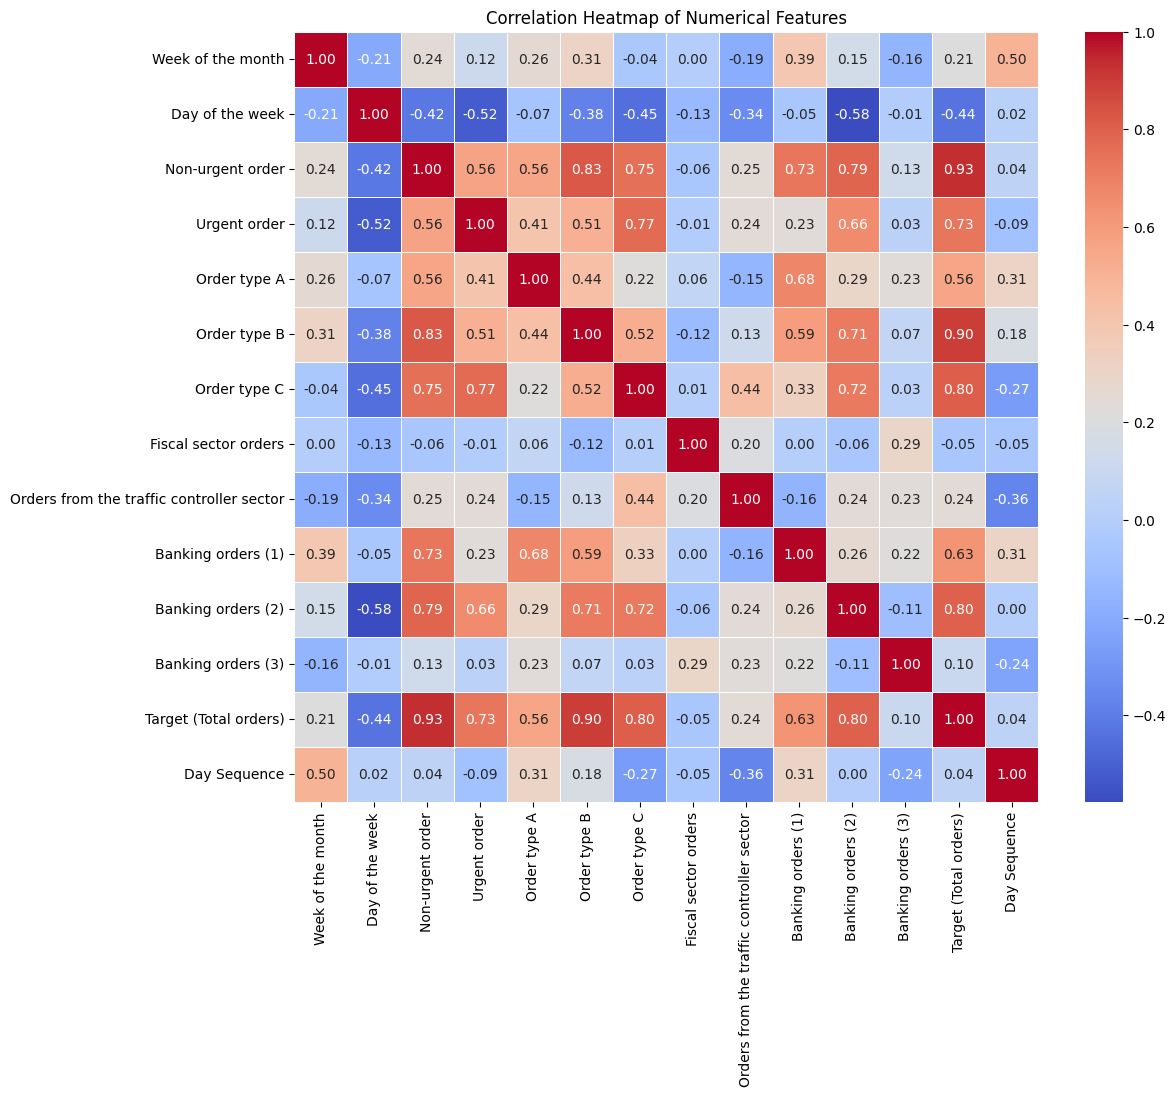

In [14]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In this heatmap:

*   **Colors:** Red shades indicate positive correlations (darker red means stronger positive correlation), while blue shades indicate negative correlations (darker blue means stronger negative correlation).
*   **Numbers:** The values in each cell are the Pearson correlation coefficients.
*   **Diagonal:** The diagonal will always be `1.00` because a variable is perfectly correlated with itself.

This visualization provides a quick overview of which features are highly correlated with each other, as well as with the 'Target (Total orders)' variable. High correlations between independent variables can sometimes indicate multicollinearity, which might be a consideration for certain modeling techniques.
In this heatmap if you can see the **red** portion the the "Non Urgent Order" and "Order Type B" has higher correlation with "Target (Total Orders)"

In [15]:
# Define features (X) and target (y)
# We will exclude 'Day Sequence' and 'Target (Total orders)' from features
# and use 'Target (Total orders)' as the dependent variable (y).

# Identify highly correlated features based on the previous correlation analysis
# Selecting features with absolute correlation > 0.5 for demonstration
high_corr_features = target_correlations[abs(target_correlations) > 0.5].index.tolist()
high_corr_features.remove('Target (Total orders)') # Remove the target itself

X = df[high_corr_features]
y = df['Target (Total orders)']

print("Features (X) selected:")
print(X.head())
print("\nTarget (y) selected:")
print(y.head())

Features (X) selected:
   Non-urgent order  Order type B  Order type C  Banking orders (2)  \
0           316.307       175.586       302.448              188411   
1           128.633        56.037       130.580               89461   
2            43.651        25.125        82.461               21305   
3           171.297       113.294       162.284               69054   
4            90.532        56.618       116.220               16411   

   Urgent order  Banking orders (1)  Order type A  
0       223.270               44914        61.543  
1        96.042               21399        38.058  
2        84.375                3452        21.826  
3       127.667               33703        41.542  
4       113.526               19646        37.679  

Target (y) selected:
0    539.577
1    224.675
2    129.412
3    317.120
4    210.517
Name: Target (Total orders), dtype: float64


## Splitting the Data into Training and Testing Sets

Before training a model, it's crucial to split our data into training and testing sets. The training set will be used to teach the model, and the testing set will be used to evaluate how well the model generalizes to unseen data. This helps prevent overfitting.

We'll use `train_test_split` from `sklearn.model_selection` for this purpose. A common practice is to allocate 80% of the data for training and 20% for testing.

In [16]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# test_size=0.20 means 20% of the data will be used for testing
# random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (48, 7)
Shape of X_test: (12, 7)
Shape of y_train: (48,)
Shape of y_test: (12,)


## Training a Linear Regression Model

With our data prepared and split, the next step is to train a machine learning model. We'll start with a simple yet powerful model: Linear Regression. This model assumes a linear relationship between the input features and the target variable.

We will use the `LinearRegression` model from `sklearn.linear_model` and fit it to our training data (`X_train` and `y_train`).

In [17]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## Visualizing Actual vs. Predicted Values

After training our Linear Regression model, it's essential to visualize its performance. We'll compare the actual `Target (Total orders)` values from the test set (`y_test`) with the values predicted by our model (`predictions`). This plot helps us understand how closely the model's predictions align with the true outcomes.

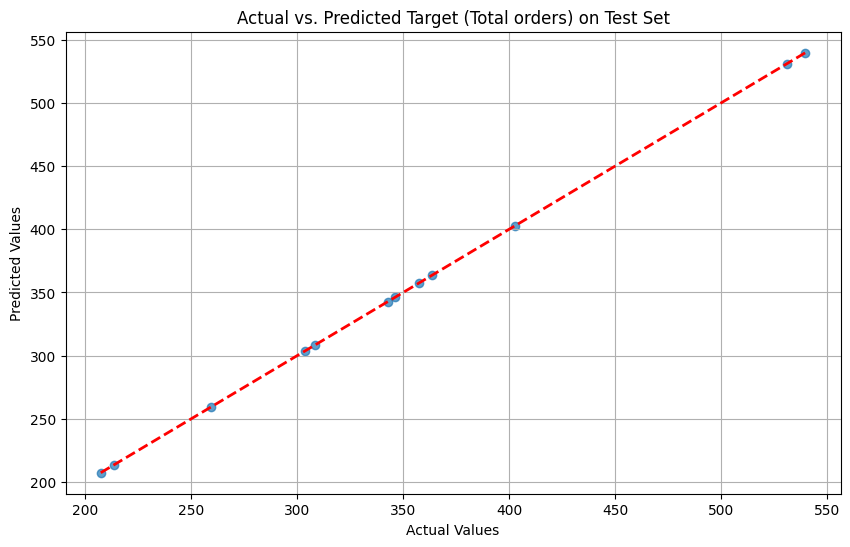

In [18]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Target (Total orders) on Test Set')
plt.grid(True)
plt.show()

In this plot:

*   Each point represents an actual `Target (Total orders)` value from the test set (`y_test`) and its corresponding predicted value (`y_pred`).
*   The **red dashed line** represents the ideal scenario where `Actual = Predicted`. Points close to this line indicate accurate predictions.

By observing how closely the points cluster around the red dashed line, we can qualitatively assess the model's performance. A tight cluster around the line suggests good predictive accuracy.

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

# Calculate R-squared (coefficient of determination)
r2 = r2_score(y_test, y_pred)
print(f'R-squared (R2): {r2:.2f}')

Root Mean Squared Error (RMSE): 0.00
R-squared (R2): 1.00
